PHASE 1

In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
print(df.head(10))



            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   
5  2025-01-01 05:00:00     19.07      72.87 -1.738494 -1.353824  299.52075   
6  2025-01-01 06:00:00     19.07      72.87 -1.340668 -1.035983  300.81470   
7  2025-01-01 07:00:00     19.07      72.87 -0.325091 -1.123993  301.37793   
8  2025-01-01 08:00:00     19.07      72.87  0.935412 -1.456282  302.09570   
9  2025-01-01 09:00:00     19.07      72.87  1.902589 -1.766295  301.76294   

           sp  number   tp  
0  101149.190       0  0.0  
1  101183.690       0  0.0  
2  101229.190       0  0.0  
3  101332.375       0  0.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("data.csv")

# Define city coordinates dictionary
city_coords = {
    (19.07, 72.87): "Mumbai",
    (13.08, 80.27): "Chennai",
    (12.97, 77.59): "Bangalore",
    (17.38, 78.48): "Hyderabad",
    (28.61, 77.20): "Delhi"
}

# Function to assign city
def get_city(lat, lon):
    return city_coords.get((round(lat,4), round(lon,4)), "Unknown")

# Apply function
df["city"] = df.apply(lambda row: get_city(row["latitude"], row["longitude"]), axis=1)

# Save file
df.to_csv("weather_with_city.csv", index=False)

print("City column added successfully")
print(df.head())

City column added successfully
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   

           sp  number   tp    city  
0  101149.190       0  0.0  Mumbai  
1  101183.690       0  0.0  Mumbai  
2  101229.190       0  0.0  Mumbai  
3  101332.375       0  0.0  Mumbai  
4  101375.625       0  0.0  Mumbai  


In [ ]:
print(df.describe())

           latitude     longitude           u10           v10           t2m  \
count  43800.000000  43800.000000  43800.000000  43800.000000  43800.000000   
mean      18.222000     77.282000      0.719071      0.062999    299.038747   
std        5.716048      2.446686      2.836666      2.166405      4.935342   
min       12.970000     72.870000     -7.918891    -10.319202    279.787840   
25%       13.080000     77.200000     -1.687578     -1.364361    296.431400   
50%       17.380000     77.590000      0.570791      0.046462    299.726070   
75%       19.070000     78.480000      2.815290      1.426009    302.107728   
max       28.610000     80.270000     10.251637      8.158779    316.614000   

                  sp   number            tp  
count   43800.000000  43800.0  43800.000000  
mean    97153.261253      0.0      0.000142  
std      3663.277639      0.0      0.000523  
min     90618.375000      0.0      0.000000  
25%     94285.358750      0.0      0.000000  
50%     9829

In [ ]:
# ============================================
# FEATURE ENGINEERING FOR VALID_TIME
# ============================================

import pandas as pd
import os

# Load dataset
data = pd.read_csv("weather.csv")

print("Original Dataset Shape:", data.shape)

# Convert valid_time to datetime
data['valid_time'] = pd.to_datetime(data['valid_time'], format='mixed')

# Create new time features
data['year'] = data['valid_time'].dt.year
data['month'] = data['valid_time'].dt.month
data['day'] = data['valid_time'].dt.day
data['hour'] = data['valid_time'].dt.hour
data['dayofweek'] = data['valid_time'].dt.dayofweek
data['dayofyear'] = data['valid_time'].dt.dayofyear
data['weekofyear'] = data['valid_time'].dt.isocalendar().week.astype(int)

# Drop original column
data = data.drop(columns=['valid_time'])

# ============================================
# DISPLAY DATA
# ============================================

print("\nNew Dataset Shape:", data.shape)

print("\nFirst 10 Rows of Feature Engineered Data:")

print(data.head(10))

# ============================================
# SAVE DATASET
# ============================================

save_path = "weather2.csv"

data.to_csv(save_path, index=False)

print("\nFeature engineered dataset saved as:", save_path)

Original Dataset Shape: (43800, 11)

New Dataset Shape: (43800, 17)

First 10 Rows of Feature Engineered Data:
   latitude  longitude       u10       v10        t2m          sp  number  \
0     19.07      72.87 -1.133946 -2.989932  296.71630  101149.190       0   
1     19.07      72.87 -1.537959 -2.689188  296.59400  101183.690       0   
2     19.07      72.87 -1.930677 -2.157767  296.54980  101229.190       0   
3     19.07      72.87 -2.025332 -1.917297  296.70825  101332.375       0   
4     19.07      72.87 -1.918789 -1.714157  297.27075  101375.625       0   
5     19.07      72.87 -1.738494 -1.353824  299.52075  101408.560       0   
6     19.07      72.87 -1.340668 -1.035983  300.81470  101364.690       0   
7     19.07      72.87 -0.325091 -1.123993  301.37793  101289.190       0   
8     19.07      72.87  0.935412 -1.456282  302.09570  101170.625       0   
9     19.07      72.87  1.902589 -1.766295  301.76294  101048.875       0   

    tp    city  wind_speed  year  month  

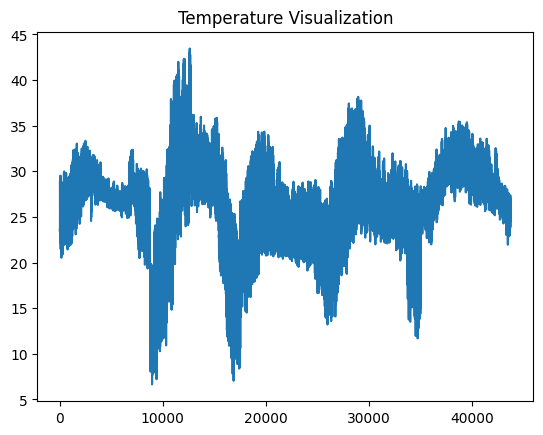

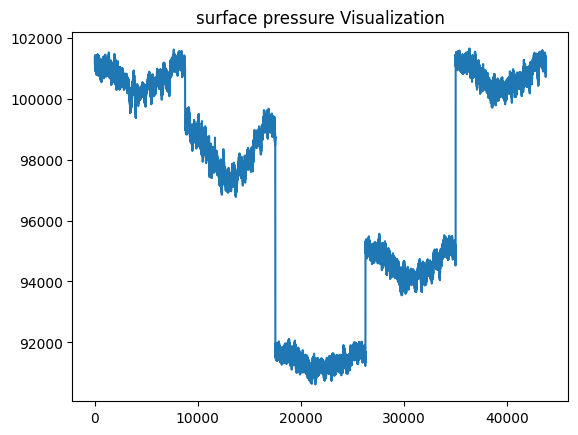

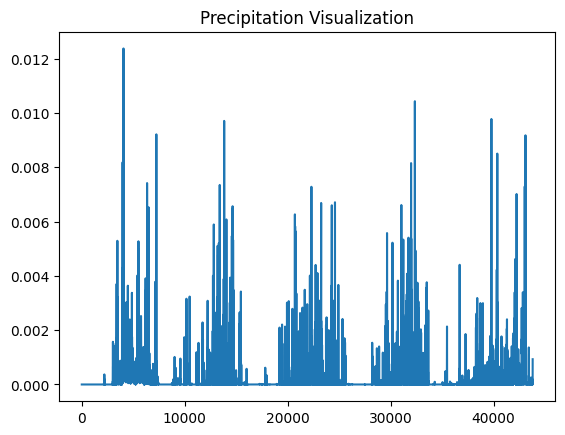

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv")

# 1. Temperature plot
plt.figure()
df['t_c'] = df['t2m'] - 273.15
plt.plot(df['t_c'])
plt.title("Temperature Visualization")
plt.show()


plt.figure()
plt.plot(df['sp'])
plt.title("surface pressure Visualization")
plt.show()

# 3. Precipitation plot
plt.figure()
plt.plot(df['tp'])
plt.title("Precipitation Visualization")
plt.show()

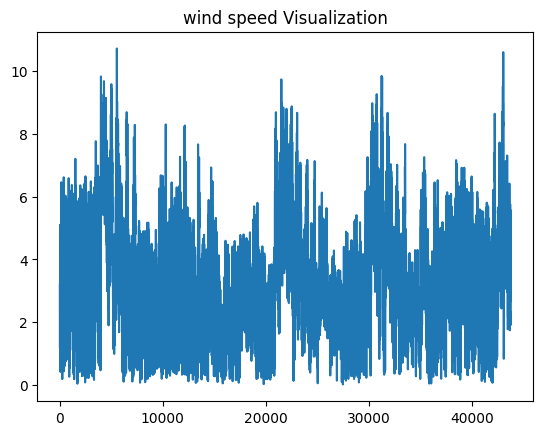

In [ ]:
plt.figure()
plt.plot(df['wind_speed'])
plt.title("wind speed Visualization")
plt.show()

           latitude  longitude       u10       v10       t2m        sp  \
latitude   1.000000  -0.322971 -0.021160 -0.096691 -0.091041  0.272505   
longitude -0.322971   1.000000 -0.181573  0.061417  0.025900 -0.216465   
u10       -0.021160  -0.181573  1.000000  0.157584  0.026789 -0.061465   
v10       -0.096691   0.061417  0.157584  1.000000  0.185703 -0.027016   
t2m       -0.091041   0.025900  0.026789  0.185703  1.000000  0.225631   
sp         0.272505  -0.216465 -0.061465 -0.027016  0.225631  1.000000   
number          NaN        NaN       NaN       NaN       NaN       NaN   
tp        -0.003967  -0.085184  0.123891  0.068901  0.019602  0.010205   

           number        tp  
latitude      NaN -0.003967  
longitude     NaN -0.085184  
u10           NaN  0.123891  
v10           NaN  0.068901  
t2m           NaN  0.019602  
sp            NaN  0.010205  
number        NaN       NaN  
tp            NaN  1.000000  


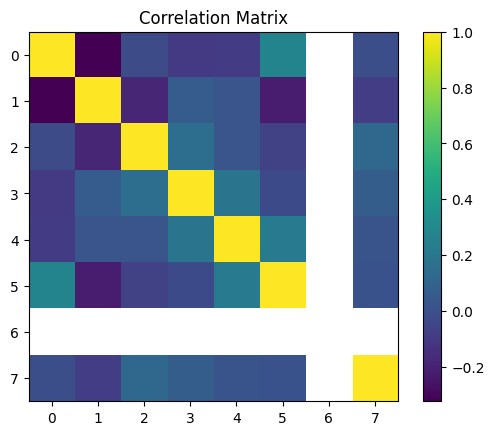

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data.csv")

# Calculate correlation, excluding non-numeric columns like 'valid_time'
# Convert 'valid_time' to datetime format first to ensure proper handling if it's needed elsewhere,
# although for correlation, we'll drop it.
df['valid_time'] = pd.to_datetime(df['valid_time'])
corr = df.drop('valid_time', axis=1).corr()

# Show correlation values
print(corr)

# Plot correlation heatmap
plt.imshow(corr)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

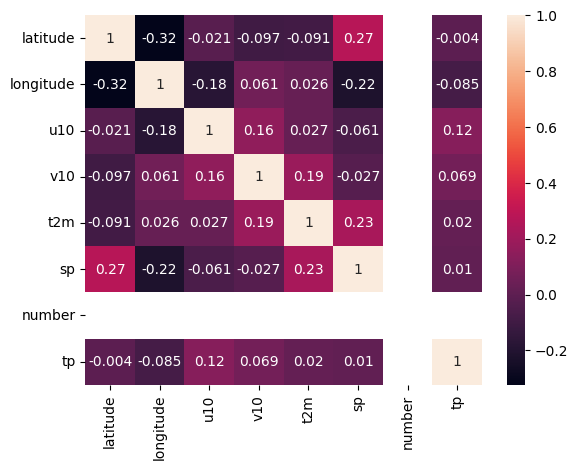

In [ ]:
import seaborn as sns

corr = df.drop('valid_time', axis=1).corr()
sns.heatmap(corr, annot=True)
plt.show()

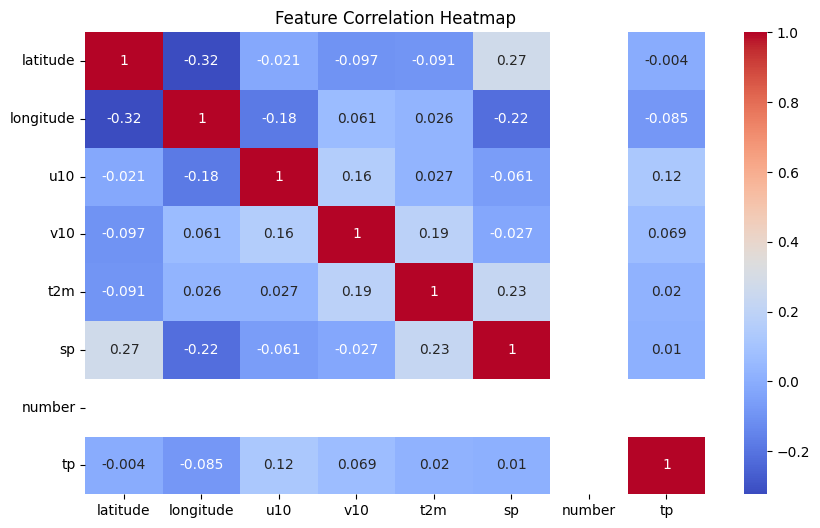

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

plt.figure(figsize=(10,6))
sns.heatmap(df.drop('valid_time', axis=1).corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
df.isnull().sum()

,0
valid_time,0
latitude,0
longitude,0
u10,0
v10,0
t2m,0
sp,0
number,0
tp,0
temp_celsius,0


In [ ]:
# ===============================
# DATA CLEANING CODE FOR ERA5 DATASET
# ===============================

import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_csv("data.csv")

# 2. Display basic info
print("Shape before cleaning:", df.shape)
print(df.info())

# 3. Remove duplicate rows
df = df.drop_duplicates()

# 4. Handle missing values

# Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill numerical missing values with mean
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 5. Convert time column to datetime format
df['valid_time'] = pd.to_datetime(df['valid_time'])

# 6. Remove invalid values (example: negative precipitation)
if 'tp' in df.columns:
    df['tp'] = df['tp'].clip(lower=0)

# 7. Reset index
df = df.reset_index(drop=True)

# 8. Final check
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("Shape after cleaning:", df.shape)



Shape before cleaning: (43800, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   valid_time  43800 non-null  object 
 1   latitude    43800 non-null  float64
 2   longitude   43800 non-null  float64
 3   u10         43800 non-null  float64
 4   v10         43800 non-null  float64
 5   t2m         43800 non-null  float64
 6   sp          43800 non-null  float64
 7   number      43800 non-null  int64  
 8   tp          43800 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 3.0+ MB
None

Missing values before cleaning:
valid_time    0
latitude      0
longitude     0
u10           0
v10           0
t2m           0
sp            0
number        0
tp            0
dtype: int64

Missing values after cleaning:
valid_time    0
latitude      0
longitude     0
u10           0
v10           0
t2m           0
sp            0
number

PHASE 2

In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm

Mounted at /content/drive
Dataset Shape: (43800, 11)
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   

           sp  number   tp    city  wind_speed  
0  101149.190       0  0.0  Mumbai    3.197738  
1  101183.690       0  0.0  Mumbai    3.097911  
2  101229.190       0  0.0  Mumbai    2.895423  
3  101332.375       0  0.0  Mumbai    2.788906  
4  101375.625       0  0.0  Mumbai    2.572953  

Training: Random Forest

Training: Gradient Boosting

Training: AdaBoost

Training: Bagging

Training: Extra Trees

Training: XGBoost

Training: LightGBM
[LightGBM] [Info] Auto-choosi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Training: HistGradientBoosting

Training: Voting Regressor

Training: Stacking Regressor

Model Performance (with physics check):
                  Model       MAE      RMSE  R2 Score  Physics Residual
0         Random Forest  0.471974  0.682767  0.980672          1.754016
1     Gradient Boosting  0.900760  1.217669  0.938524          1.647840
2              AdaBoost  1.967328  2.452104  0.750700          1.114775
3               Bagging  0.474700  0.687657  0.980394          1.751897
4           Extra Trees  0.413652  0.590644  0.985536          1.779020
5               XGBoost  0.654677  0.888902  0.967239          1.719890
6              LightGBM  0.701243  0.928502  0.964255          1.722828
7  HistGradientBoosting  0.613081  0.818452  0.972226          1.757976
8      Voting Regressor  0.532922  0.734249  0.977647          1.710354
9    Stacking Regressor  0.409832  0.590384  0.985548          1.807886

Results saved to /content/drive/MyDrive/weather_project


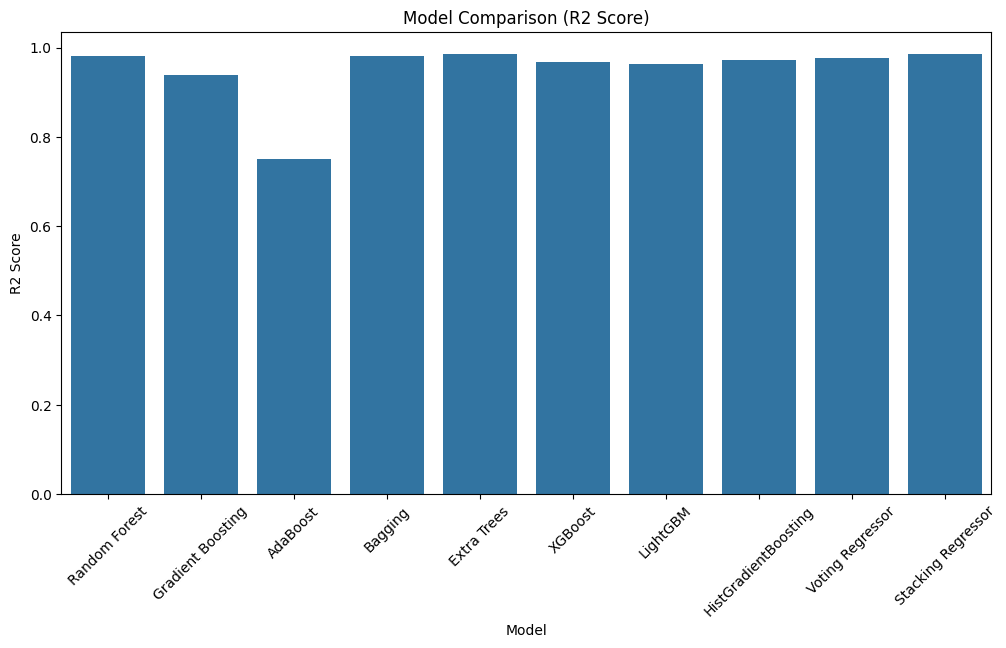

Best Model: Stacking Regressor


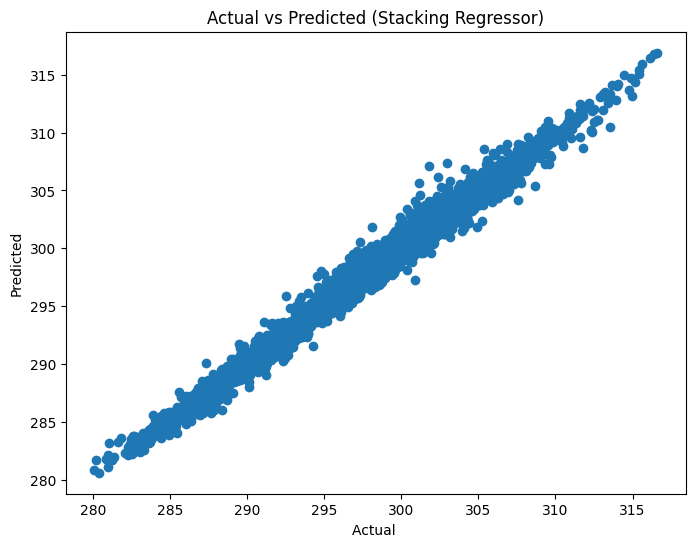

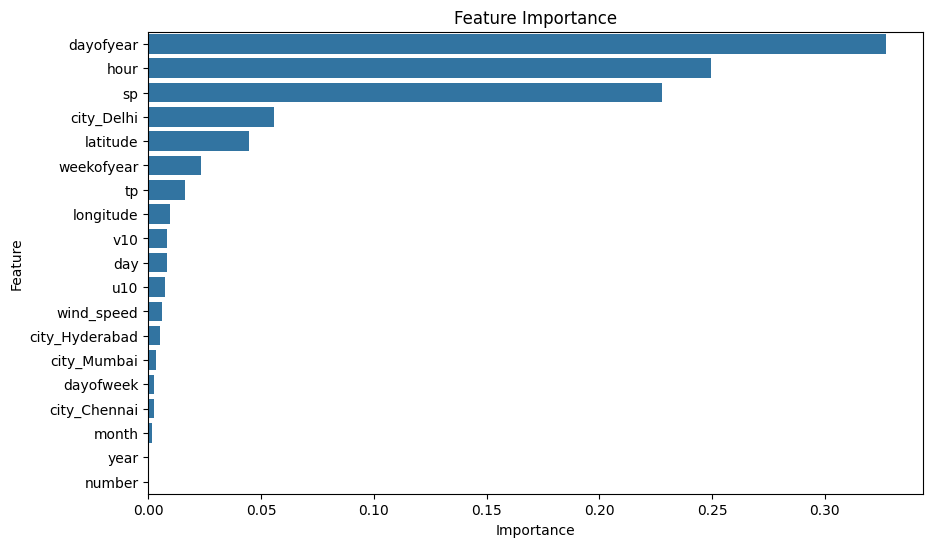

In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION (ENSEMBLES + PHYSICS CHECK)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,z
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================
# STEP 0: MOUNT DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/weather_project"
os.makedirs(SAVE_PATH, exist_ok=True)

# ============================================
# STEP 1: LOAD DATASET
# ============================================
data = pd.read_csv("/content/drive/MyDrive/weather.csv")
print("Dataset Shape:", data.shape)
print(data.head())

# Feature Engineering for 'valid_time'
data['valid_time'] = pd.to_datetime(data['valid_time'])
data['year'] = data['valid_time'].dt.year
data['month'] = data['valid_time'].dt.month
data['day'] = data['valid_time'].dt.day
data['hour'] = data['valid_time'].dt.hour
data['dayofweek'] = data['valid_time'].dt.dayofweek
data['dayofyear'] = data['valid_time'].dt.dayofyear
data['weekofyear'] = data['valid_time'].dt.isocalendar().week.astype(int)
data = data.drop(columns=['valid_time'])

# ============================================
# STEP 2: DEFINE FEATURES AND TARGET
# ============================================
target = "t2m"
X = data.drop(columns=[target])
y = data[target]

# Handle categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ============================================
# STEP 3: TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 4: SCALE FEATURES
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# STEP 5: DEFINE ENSEMBLE MODELS
# ============================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200),
    "AdaBoost": AdaBoostRegressor(n_estimators=200),
    "Bagging": BaggingRegressor(n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200)
}

# ============================================
# STEP 6: VOTING REGRESSOR
# ============================================
voting_model = VotingRegressor([
    ('rf', models["Random Forest"]),
    ('gb', models["Gradient Boosting"]),
    ('et', models["Extra Trees"])
])
models["Voting Regressor"] = voting_model

# ============================================
# STEP 7: STACKING REGRESSOR
# ============================================
stacking_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('gb', GradientBoostingRegressor()),
        ('et', ExtraTreesRegressor())
    ],
    final_estimator=LinearRegression()
)
models["Stacking Regressor"] = stacking_model

# ============================================
# STEP 8: TRAIN MODELS + DATA LOSS + PHYSICS CHECK
# ============================================
results = []
predictions_dict = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions_dict[name] = y_pred

    # Data metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Physics residual (simple finite difference check)
    # Example: dT/dt + u*dT/dx + v*dT/dy ≈ 0
    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    dy = X_test_scaled[:,1].max() - X_test_scaled[:,1].min() + 1e-6

    u = X_test_scaled[:,7] if X_test_scaled.shape[1] > 7 else np.zeros_like(y_pred)
    v = X_test_scaled[:,8] if X_test_scaled.shape[1] > 8 else np.zeros_like(y_pred)

    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    dT_dy = np.gradient(y_pred, axis=0) / dy

    physics_residual = np.mean((dT_dt + u*dT_dx + v*dT_dy)**2)

    results.append([name, mae, rmse, r2, physics_residual])

# ============================================
# STEP 9: RESULTS TABLE + SAVE
# ============================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score", "Physics Residual"]
)
print("\nModel Performance (with physics check):")
print(results_df)

results_df.to_csv(os.path.join(SAVE_PATH, "temperature_results_with_physics.csv"), index=False)
print(f"\nResults saved to {SAVE_PATH}")

# ============================================
# STEP 10: MODEL COMPARISON GRAPH
# ============================================
plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

# ============================================
# STEP 11: ACTUAL vs PREDICTED GRAPH (Best Model)
# ============================================
best_model_name = results_df.sort_values("R2 Score", ascending=False)["Model"].iloc[0]
print("Best Model:", best_model_name)

y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual ")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# ============================================
# STEP 12: FEATURE IMPORTANCE (Random Forest)
# ============================================
rf_model = models["Random Forest"]
importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
importance_df = importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (43800, 11)
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   

           sp  number   tp    city  wind_speed  
0  101149.190       0  0.0  Mumbai    3.197738  
1  101183.690       0  0.0  Mumbai    3.097911  
2  101229.190       0  0.0  Mumbai    2.895423  
3  101332.375       0  0.0  Mumbai    2.788906  
4  101375.625       0  0.0  Mumbai    2.572953  

Training: Random Forest

Training: Gradient Boosting

Training: AdaBoost

Traini

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Training: HistGradientBoosting

Training: Voting Regressor

Training: Stacking Regressor

Model Performance (with physics check):
                  Model         MAE        RMSE  R2 Score  Physics Residual
0         Random Forest   48.339665   63.680639  0.999699     976691.517821
1     Gradient Boosting   96.733834  126.871149  0.998806     972208.511576
2              AdaBoost  319.113589  411.775870  0.987420     967069.840442
3               Bagging   48.573578   63.914371  0.999697     976967.642882
4           Extra Trees   37.513055   48.736290  0.999824     978112.389571
5               XGBoost   70.139403   93.541996  0.999351     975584.443058
6              LightGBM   69.031566   88.714051  0.999416     974820.471954
7  HistGradientBoosting   54.291627   70.152932  0.999635     977012.459667
8      Voting Regressor   53.360106   68.321031  0.999654     975462.278327
9    Stacking Regressor   37.285246   48.470332  0.999826     978863.038097

Results saved to /content/drive/

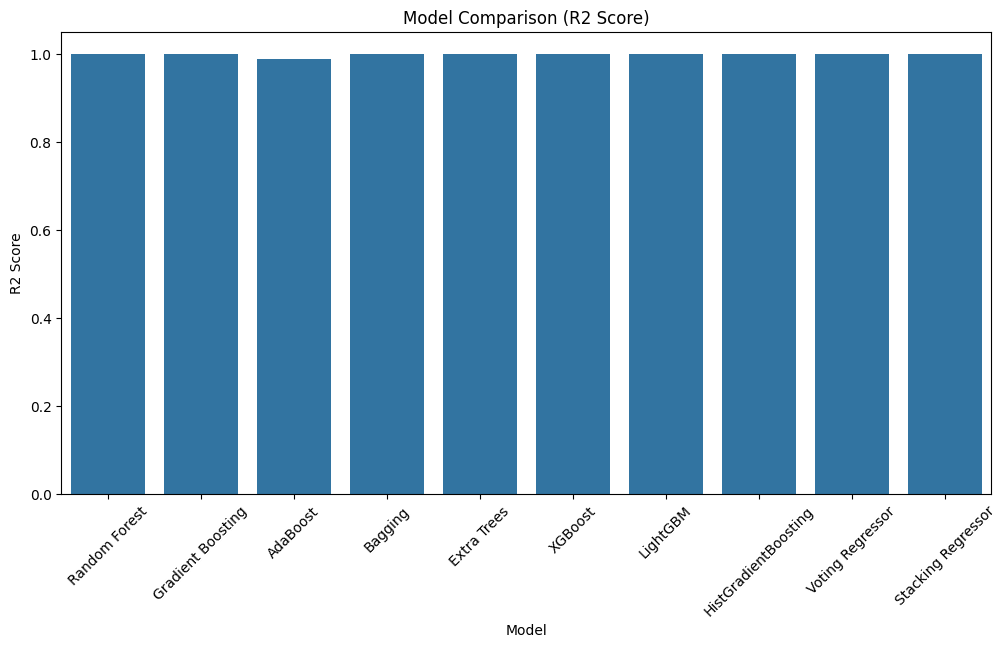

Best Model: Stacking Regressor


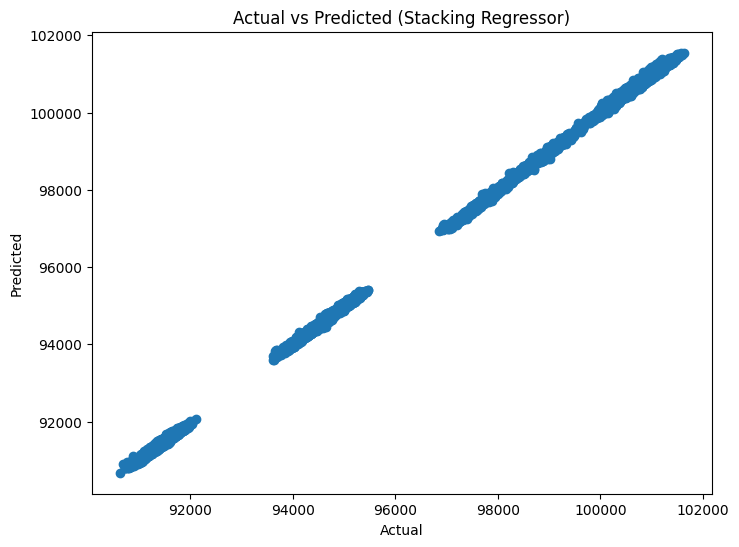

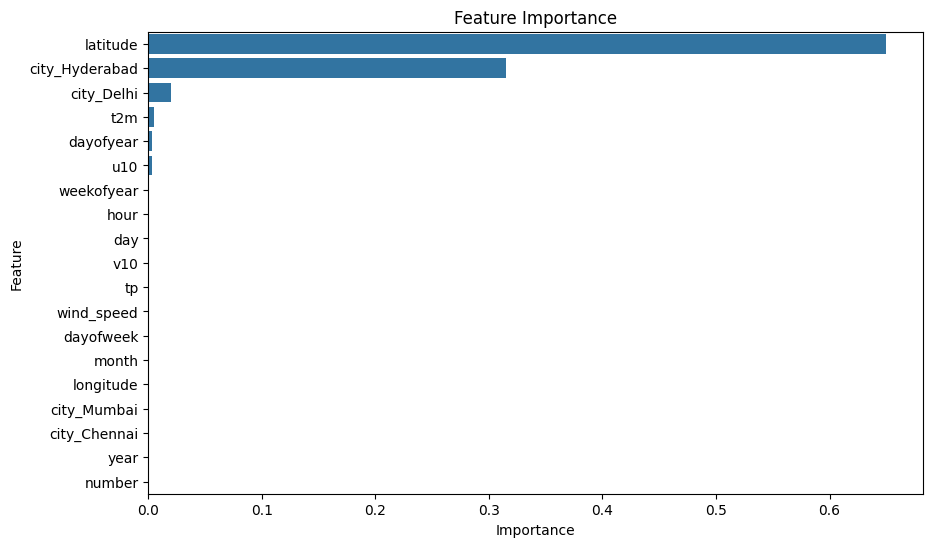

In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION (ENSEMBLES + PHYSICS CHECK)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================
# STEP 0: MOUNT DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/weather_project"
os.makedirs(SAVE_PATH, exist_ok=True)

# ============================================
# STEP 1: LOAD DATASET
# ============================================
data = pd.read_csv("/content/drive/MyDrive/weather.csv")
print("Dataset Shape:", data.shape)
print(data.head())

# Feature Engineering for 'valid_time'
data['valid_time'] = pd.to_datetime(data['valid_time'])
data['year'] = data['valid_time'].dt.year
data['month'] = data['valid_time'].dt.month
data['day'] = data['valid_time'].dt.day
data['hour'] = data['valid_time'].dt.hour
data['dayofweek'] = data['valid_time'].dt.dayofweek
data['dayofyear'] = data['valid_time'].dt.dayofyear
data['weekofyear'] = data['valid_time'].dt.isocalendar().week.astype(int)
data = data.drop(columns=['valid_time'])

# ============================================
# STEP 2: DEFINE FEATURES AND TARGET
# ============================================
target = "sp"
X = data.drop(columns=[target])
y = data[target]

# Handle categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ============================================
# STEP 3: TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 4: SCALE FEATURES
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# STEP 5: DEFINE ENSEMBLE MODELS
# ============================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200),
    "AdaBoost": AdaBoostRegressor(n_estimators=200),
    "Bagging": BaggingRegressor(n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200)
}

# ============================================
# STEP 6: VOTING REGRESSOR
# ============================================
voting_model = VotingRegressor([
    ('rf', models["Random Forest"]),
    ('gb', models["Gradient Boosting"]),
    ('et', models["Extra Trees"])
])
models["Voting Regressor"] = voting_model

# ============================================
# STEP 7: STACKING REGRESSOR
# ============================================
stacking_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('gb', GradientBoostingRegressor()),
        ('et', ExtraTreesRegressor())
    ],
    final_estimator=LinearRegression()
)
models["Stacking Regressor"] = stacking_model

# ============================================
# STEP 8: TRAIN MODELS + DATA LOSS + PHYSICS CHECK
# ============================================
results = []
predictions_dict = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions_dict[name] = y_pred

    # Data metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Physics residual (simple finite difference check)
    # Example: dT/dt + u*dT/dx + v*dT/dy ≈ 0
    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    dy = X_test_scaled[:,1].max() - X_test_scaled[:,1].min() + 1e-6

    u = X_test_scaled[:,7] if X_test_scaled.shape[1] > 7 else np.zeros_like(y_pred)
    v = X_test_scaled[:,8] if X_test_scaled.shape[1] > 8 else np.zeros_like(y_pred)

    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    dT_dy = np.gradient(y_pred, axis=0) / dy

    physics_residual = np.mean((dT_dt + u*dT_dx + v*dT_dy)**2)

    results.append([name, mae, rmse, r2, physics_residual])

# ============================================
# STEP 9: RESULTS TABLE + SAVE
# ============================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score", "Physics Residual"]
)
print("\nModel Performance (with physics check):")
print(results_df)

results_df.to_csv(os.path.join(SAVE_PATH, "pressure_results_with_physics.csv"), index=False)
print(f"\nResults saved to {SAVE_PATH}")

# ============================================
# STEP 10: MODEL COMPARISON GRAPH
# ============================================
plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

# ============================================
# STEP 11: ACTUAL vs PREDICTED GRAPH (Best Model)
# ============================================
best_model_name = results_df.sort_values("R2 Score", ascending=False)["Model"].iloc[0]
print("Best Model:", best_model_name)

y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# ============================================
# STEP 12: FEATURE IMPORTANCE (Random Forest)
# ============================================
rf_model = models["Random Forest"]
importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
importance_df = importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (43800, 11)
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   

           sp  number   tp    city  wind_speed  
0  101149.190       0  0.0  Mumbai    3.197738  
1  101183.690       0  0.0  Mumbai    3.097911  
2  101229.190       0  0.0  Mumbai    2.895423  
3  101332.375       0  0.0  Mumbai    2.788906  
4  101375.625       0  0.0  Mumbai    2.572953  

Training: Random Forest

Training: Gradient Boosting

Training: AdaBoost

Traini

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Training: HistGradientBoosting

Training: Voting Regressor

Training: Stacking Regressor

Model Performance (with physics check):
                  Model       MAE      RMSE  R2 Score  Physics Residual
0         Random Forest  0.014950  0.038478  0.999433          0.126694
1     Gradient Boosting  0.047201  0.073199  0.997947          0.125983
2              AdaBoost  0.578951  0.736148  0.792370          0.102204
3               Bagging  0.015130  0.038612  0.999429          0.126689
4           Extra Trees  0.018194  0.042230  0.999317          0.125247
5               XGBoost  0.029979  0.068332  0.998211          0.124270
6              LightGBM  0.034089  0.073771  0.997915          0.124935
7  HistGradientBoosting  0.034137  0.070741  0.998083          0.126558
8      Voting Regressor  0.018689  0.038563  0.999430          0.125731
9    Stacking Regressor  0.015733  0.037119  0.999472          0.126593

Results saved to /content/drive/MyDrive/weather_project


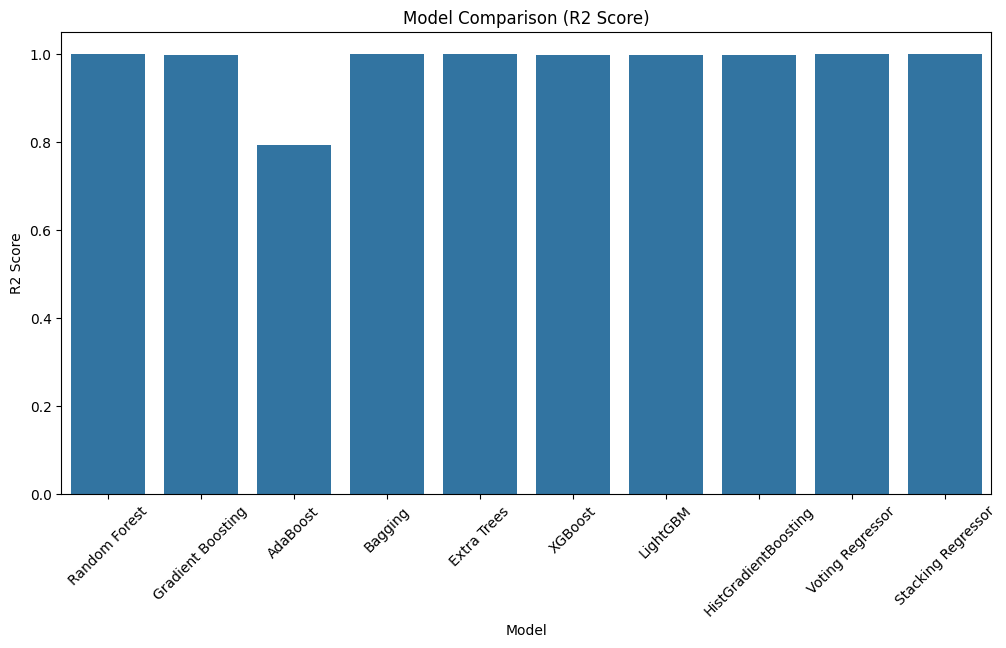

Best Model: Stacking Regressor


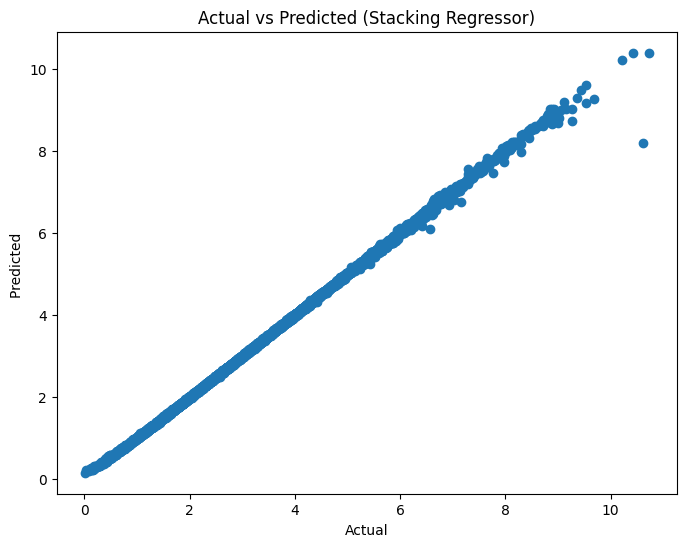

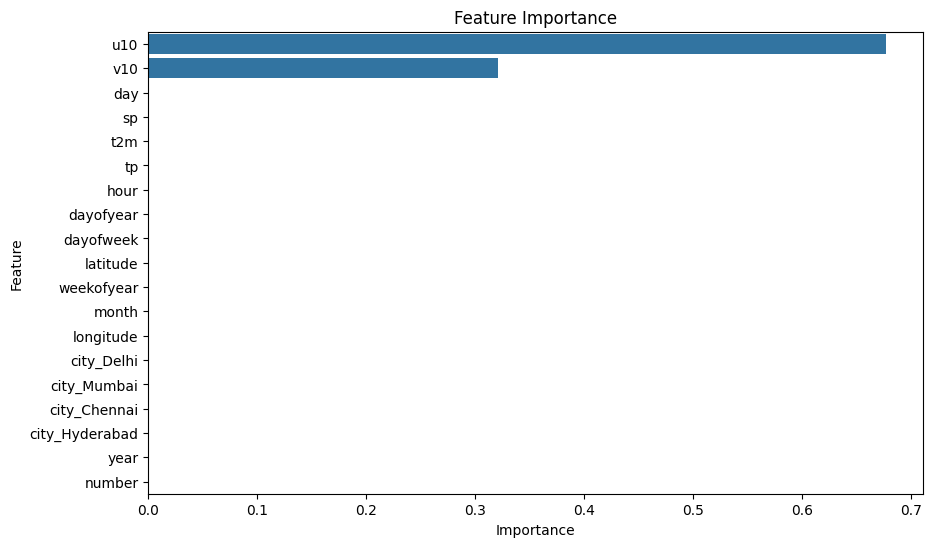

In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION (ENSEMBLES + PHYSICS CHECK)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================
# STEP 0: MOUNT DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/weather_project"
os.makedirs(SAVE_PATH, exist_ok=True)

# ============================================
# STEP 1: LOAD DATASET
# ============================================
data = pd.read_csv("/content/drive/MyDrive/weather.csv")
print("Dataset Shape:", data.shape)
print(data.head())

# Feature Engineering for 'valid_time'
data['valid_time'] = pd.to_datetime(data['valid_time'])
data['year'] = data['valid_time'].dt.year
data['month'] = data['valid_time'].dt.month
data['day'] = data['valid_time'].dt.day
data['hour'] = data['valid_time'].dt.hour
data['dayofweek'] = data['valid_time'].dt.dayofweek
data['dayofyear'] = data['valid_time'].dt.dayofyear
data['weekofyear'] = data['valid_time'].dt.isocalendar().week.astype(int)
data = data.drop(columns=['valid_time'])

# ============================================
# STEP 2: DEFINE FEATURES AND TARGET
# ============================================
target = "wind_speed"
X = data.drop(columns=[target])
y = data[target]

# Handle categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ============================================
# STEP 3: TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 4: SCALE FEATURES
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# STEP 5: DEFINE ENSEMBLE MODELS
# ============================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200),
    "AdaBoost": AdaBoostRegressor(n_estimators=200),
    "Bagging": BaggingRegressor(n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200)
}

# ============================================
# STEP 6: VOTING REGRESSOR
# ============================================
voting_model = VotingRegressor([
    ('rf', models["Random Forest"]),
    ('gb', models["Gradient Boosting"]),
    ('et', models["Extra Trees"])
])
models["Voting Regressor"] = voting_model

# ============================================
# STEP 7: STACKING REGRESSOR
# ============================================
stacking_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('gb', GradientBoostingRegressor()),
        ('et', ExtraTreesRegressor())
    ],
    final_estimator=LinearRegression()
)
models["Stacking Regressor"] = stacking_model

# ============================================
# STEP 8: TRAIN MODELS + DATA LOSS + PHYSICS CHECK
# ============================================
results = []
predictions_dict = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions_dict[name] = y_pred

    # Data metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Physics residual (simple finite difference check)
    # Example: dT/dt + u*dT/dx + v*dT/dy ≈ 0
    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    dy = X_test_scaled[:,1].max() - X_test_scaled[:,1].min() + 1e-6

    u = X_test_scaled[:,7] if X_test_scaled.shape[1] > 7 else np.zeros_like(y_pred)
    v = X_test_scaled[:,8] if X_test_scaled.shape[1] > 8 else np.zeros_like(y_pred)

    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    dT_dy = np.gradient(y_pred, axis=0) / dy

    physics_residual = np.mean((dT_dt + u*dT_dx + v*dT_dy)**2)

    results.append([name, mae, rmse, r2, physics_residual])

# ============================================
# STEP 9: RESULTS TABLE + SAVE
# ============================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score", "Physics Residual"]
)
print("\nModel Performance (with physics check):")
print(results_df)

results_df.to_csv(os.path.join(SAVE_PATH, "windspeed_results_with_physics.csv"), index=False)
print(f"\nResults saved to {SAVE_PATH}")

# ============================================
# STEP 10: MODEL COMPARISON GRAPH
# ============================================
plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

# ============================================
# STEP 11: ACTUAL vs PREDICTED GRAPH (Best Model)
# ============================================
best_model_name = results_df.sort_values("R2 Score", ascending=False)["Model"].iloc[0]
print("Best Model:", best_model_name)

y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted ")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# ============================================
# STEP 12: FEATURE IMPORTANCE (Random Forest)
# ============================================
rf_model = models["Random Forest"]
importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
importance_df = importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (43800, 11)
            valid_time  latitude  longitude       u10       v10        t2m  \
0  2025-01-01 00:00:00     19.07      72.87 -1.133946 -2.989932  296.71630   
1  2025-01-01 01:00:00     19.07      72.87 -1.537959 -2.689188  296.59400   
2  2025-01-01 02:00:00     19.07      72.87 -1.930677 -2.157767  296.54980   
3  2025-01-01 03:00:00     19.07      72.87 -2.025332 -1.917297  296.70825   
4  2025-01-01 04:00:00     19.07      72.87 -1.918789 -1.714157  297.27075   

           sp  number   tp    city  wind_speed  
0  101149.190       0  0.0  Mumbai    3.197738  
1  101183.690       0  0.0  Mumbai    3.097911  
2  101229.190       0  0.0  Mumbai    2.895423  
3  101332.375       0  0.0  Mumbai    2.788906  
4  101375.625       0  0.0  Mumbai    2.572953  

Training: Random Forest

Training: Gradient Boosting

Training: AdaBoost

Traini

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Training: HistGradientBoosting

Training: Voting Regressor

Training: Stacking Regressor

Model Performance (with physics check):
                  Model       MAE      RMSE  R2 Score  Physics Residual
0         Random Forest  0.000103  0.000300  0.612684      8.730221e-09
1     Gradient Boosting  0.000156  0.000394  0.329095      3.979735e-09
2              AdaBoost  0.000429  0.000643 -0.783641      1.396487e-08
3               Bagging  0.000103  0.000301  0.610325      8.713812e-09
4           Extra Trees  0.000080  0.000251  0.728832      1.277778e-08
5               XGBoost  0.000135  0.000355  0.454731      4.751247e-09
6              LightGBM  0.000121  0.000327  0.538141      6.841577e-09
7  HistGradientBoosting  0.000164  0.000399  0.312939      1.778884e-09
8      Voting Regressor  0.000107  0.000293  0.628470      7.043548e-09
9    Stacking Regressor  0.000083  0.000252  0.725248      1.550100e-08

Results saved to /content/drive/MyDrive/weather_project


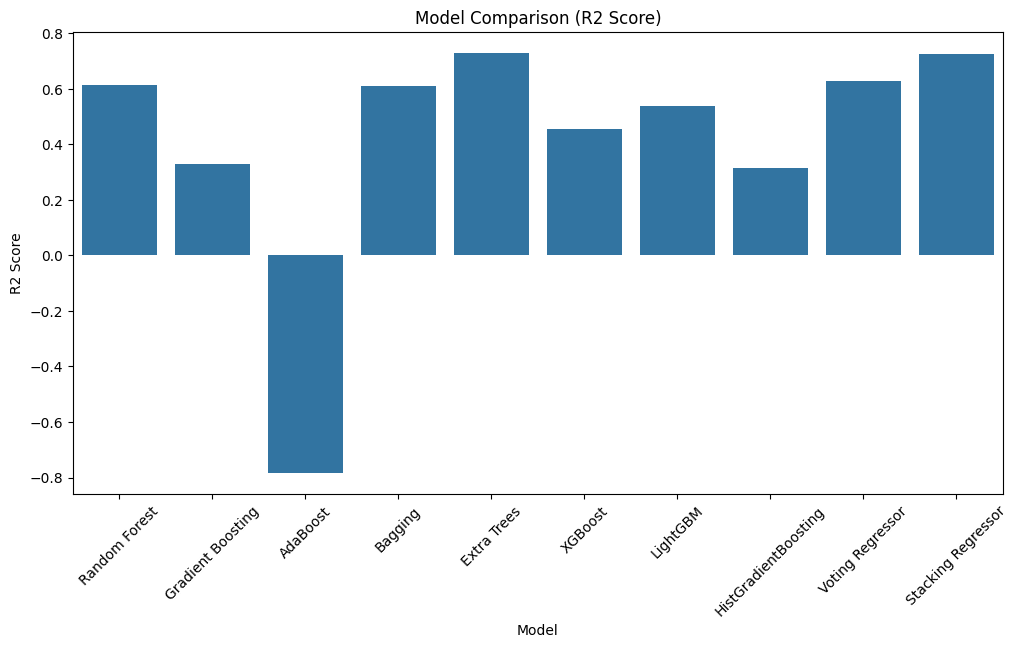

Best Model: Extra Trees


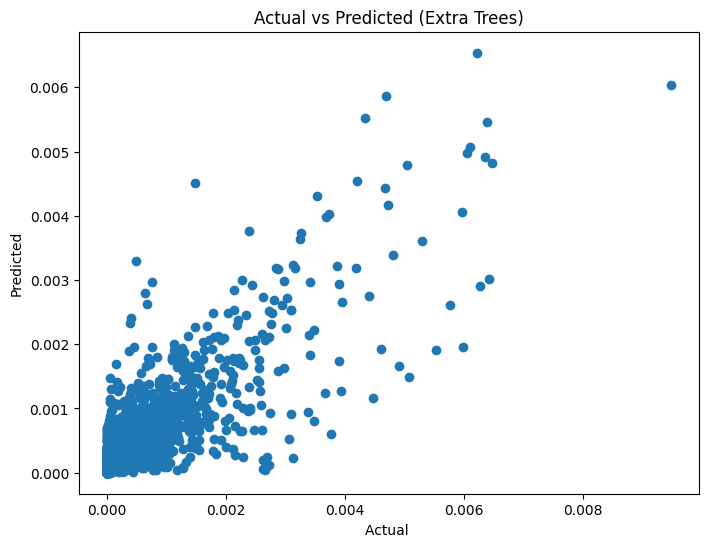

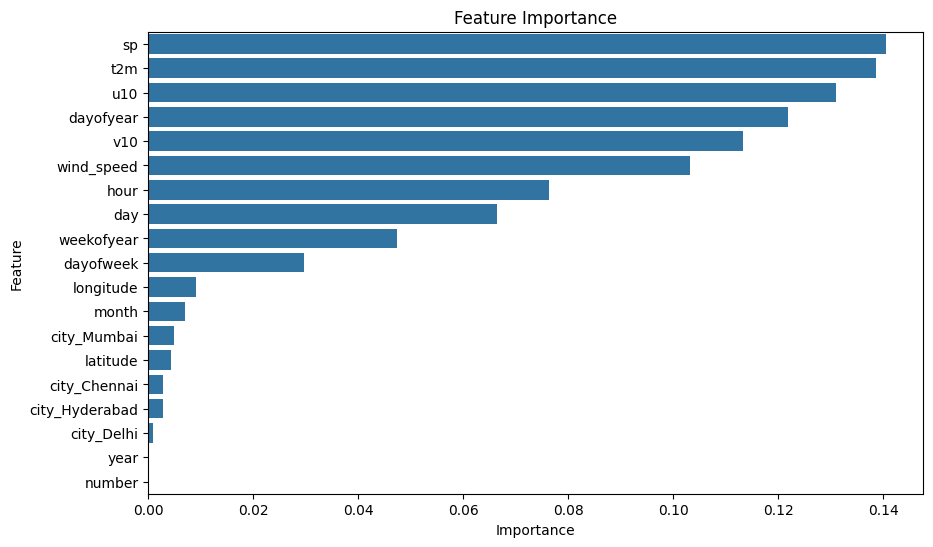

In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION (ENSEMBLES + PHYSICS CHECK)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ============================================
# STEP 0: MOUNT DRIVE
# ============================================
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/weather_project"
os.makedirs(SAVE_PATH, exist_ok=True)

# ============================================
# STEP 1: LOAD DATASET
# ============================================
data = pd.read_csv("/content/drive/MyDrive/weather.csv")
print("Dataset Shape:", data.shape)
print(data.head())

# Feature Engineering for 'valid_time'
data['valid_time'] = pd.to_datetime(data['valid_time'])
data['year'] = data['valid_time'].dt.year
data['month'] = data['valid_time'].dt.month
data['day'] = data['valid_time'].dt.day
data['hour'] = data['valid_time'].dt.hour
data['dayofweek'] = data['valid_time'].dt.dayofweek
data['dayofyear'] = data['valid_time'].dt.dayofyear
data['weekofyear'] = data['valid_time'].dt.isocalendar().week.astype(int)
data = data.drop(columns=['valid_time'])

# ============================================
# STEP 2: DEFINE FEATURES AND TARGET
# ============================================
target = "tp"
X = data.drop(columns=[target])
y = data[target]

# Handle categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# ============================================
# STEP 3: TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# STEP 4: SCALE FEATURES
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# STEP 5: DEFINE ENSEMBLE MODELS
# ============================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200),
    "AdaBoost": AdaBoostRegressor(n_estimators=200),
    "Bagging": BaggingRegressor(n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200)
}

# ============================================
# STEP 6: VOTING REGRESSOR
# ============================================
voting_model = VotingRegressor([
    ('rf', models["Random Forest"]),
    ('gb', models["Gradient Boosting"]),
    ('et', models["Extra Trees"])
])
models["Voting Regressor"] = voting_model

# ============================================
# STEP 7: STACKING REGRESSOR
# ============================================
stacking_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor()),
        ('gb', GradientBoostingRegressor()),
        ('et', ExtraTreesRegressor())
    ],
    final_estimator=LinearRegression()
)
models["Stacking Regressor"] = stacking_model

# ============================================
# STEP 8: TRAIN MODELS + DATA LOSS + PHYSICS CHECK
# ============================================
results = []
predictions_dict = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions_dict[name] = y_pred

    # Data metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Physics residual (simple finite difference check)
    # Example: dT/dt + u*dT/dx + v*dT/dy ≈ 0
    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    dy = X_test_scaled[:,1].max() - X_test_scaled[:,1].min() + 1e-6

    u = X_test_scaled[:,7] if X_test_scaled.shape[1] > 7 else np.zeros_like(y_pred)
    v = X_test_scaled[:,8] if X_test_scaled.shape[1] > 8 else np.zeros_like(y_pred)

    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    dT_dy = np.gradient(y_pred, axis=0) / dy

    physics_residual = np.mean((dT_dt + u*dT_dx + v*dT_dy)**2)

    results.append([name, mae, rmse, r2, physics_residual])

# ============================================
# STEP 9: RESULTS TABLE + SAVE
# ============================================
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score", "Physics Residual"]
)
print("\nModel Performance (with physics check):")
print(results_df)

results_df.to_csv(os.path.join(SAVE_PATH, "precipitation_results_with_physics.csv"), index=False)
print(f"\nResults saved to {SAVE_PATH}")

# ============================================
# STEP 10: MODEL COMPARISON GRAPH
# ============================================
plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.show()

# ============================================
# STEP 11: ACTUAL vs PREDICTED GRAPH (Best Model)
# ============================================
best_model_name = results_df.sort_values("R2 Score", ascending=False)["Model"].iloc[0]
print("Best Model:", best_model_name)

y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual ")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

# ============================================
# STEP 12: FEATURE IMPORTANCE (Random Forest)
# ============================================
rf_model = models["Random Forest"]
importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
importance_df = importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

PHASE 3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (43800, 17)
   latitude  longitude       u10       v10        t2m          sp  number  \
0     19.07      72.87 -1.133946 -2.989932  296.71630  101149.190       0   
1     19.07      72.87 -1.537959 -2.689188  296.59400  101183.690       0   
2     19.07      72.87 -1.930677 -2.157767  296.54980  101229.190       0   
3     19.07      72.87 -2.025332 -1.917297  296.70825  101332.375       0   
4     19.07      72.87 -1.918789 -1.714157  297.27075  101375.625       0   

    tp    city  wind_speed  year  month  day  hour  dayofweek  dayofyear  \
0  0.0  Mumbai    3.197738  2025      1    1     0          2          1   
1  0.0  Mumbai    3.097911  2025      1    1     1          2          1   
2  0.0  Mumbai    2.895423  2025      1    1     2          2          1   
3  0.0  Mumbai    2.788906  2025      1    1     3          2          1   
4

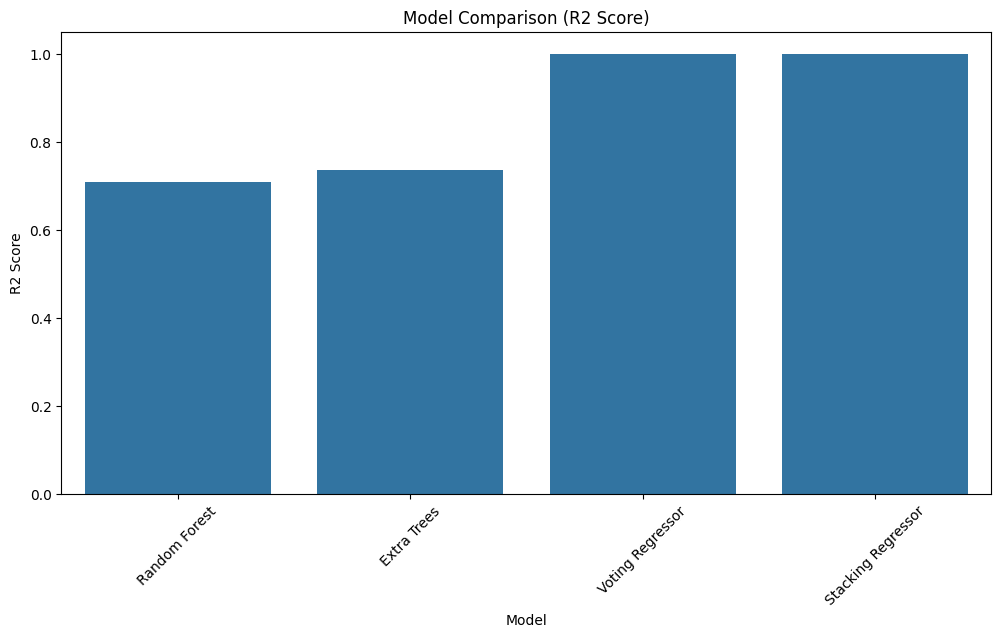

Best Model: Stacking Regressor


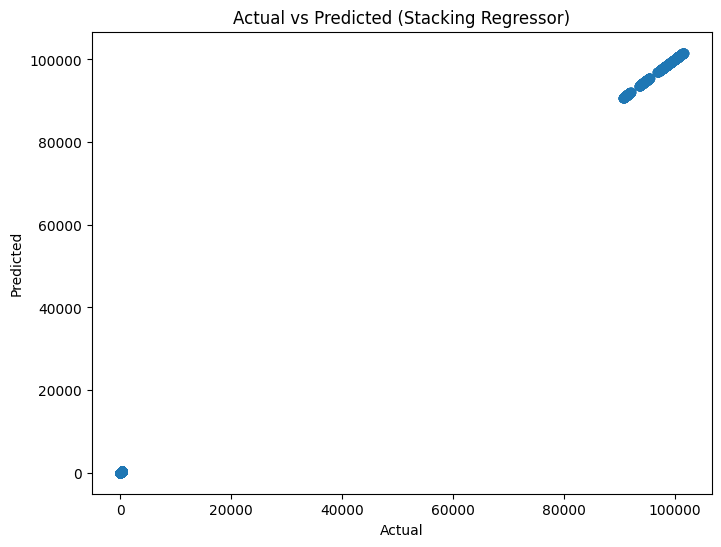

In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION
# (10 MODELS + FINE TUNING + PHYSICS CHECK)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Import MultiOutputRegressor
from sklearn.multioutput import MultiOutputRegressor

# ============================================
# STEP 0: MOUNT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/weather_project3/"


os.makedirs(MODEL_PATH, exist_ok=True)

# ============================================
# STEP 1: LOAD DATASET
# ============================================

data = pd.read_csv("/content/drive/MyDrive/weather_project3/weather2.csv")

print("Dataset Shape:", data.shape)
print(data.head())

X = data[['latitude','longitude','t2m','sp','tp','wind_speed','year','month','day','hour']]
y = data[['t2m','sp','tp','wind_speed']]

# ============================================
# STEP 4: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# ============================================
# STEP 5: SCALE FEATURES
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
# joblib.dump(scaler, os.path.join(MODEL_PATH,"scaler.pkl"))

# ============================================
# STEP 6: DEFINE MODELS
# ============================================

models = {

"Random Forest": RandomForestRegressor(random_state=42),

"Extra Trees": ExtraTreesRegressor(random_state=42),

}

# ============================================
# VOTING REGRESSOR
# ============================================

models["Voting Regressor"] = MultiOutputRegressor(VotingRegressor([

('rf', RandomForestRegressor(random_state=42)),
('gb', GradientBoostingRegressor(random_state=42)),
('et', ExtraTreesRegressor(random_state=42))

]))

# ============================================
# STACKING REGRESSOR
# ============================================

models["Stacking Regressor"] = MultiOutputRegressor(StackingRegressor(

estimators=[

('rf', RandomForestRegressor(random_state=42)),
('gb', GradientBoostingRegressor(random_state=42)),
('et', ExtraTreesRegressor(random_state=42))

],

final_estimator=LinearRegression()

))

# ============================================
# PARAMETER GRIDS FOR FINE TUNING
# ============================================

param_grids = {

"Random Forest": {
"n_estimators":[100,200],
"max_depth":[10,None]
},

"Gradient Boosting": {
"n_estimators":[100,200],
"learning_rate":[0.05,0.1]
},

"AdaBoost": {
"n_estimators":[100,200],
"learning_rate":[0.05,0.1]
},

"Extra Trees": {
"n_estimators":[100,200],
"max_depth":[10,None]
},

"XGBoost": {
"n_estimators":[100,200],
"learning_rate":[0.05,0.1]
},

"LightGBM": {
"n_estimators":[100,200],
"learning_rate":[0.05,0.1]
}

}

# ============================================
# STEP 7: TRAIN + FINE TUNE + PHYSICS CHECK
# ============================================

results = []
predictions_dict = {}

for name, model in models.items():

    print("\nTraining:", name)

    if name in param_grids:

        grid = GridSearchCV(
            model,
            param_grids[name],
            cv=3,
            n_jobs=-1
        )

        grid.fit(X_train_scaled, y_train)

        best_model = grid.best_estimator_

        print("Best Params:", grid.best_params_)

    else:

        best_model = model.fit(X_train_scaled, y_train)

    # Save trained model
    # model_file = os.path.join(MODEL_PATH, name.replace(" ","_") + ".pkl")
    # joblib.dump(best_model, model_file)

    # print("Model saved:", model_file)

    y_pred = best_model.predict(X_test_scaled)

    predictions_dict[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # ============================================
    # PHYSICS RESIDUAL CHECK
    # ============================================

    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    dy = X_test_scaled[:,1].max() - X_test_scaled[:,1].min() + 1e-6

    # Extract u and v, ensuring they are 1D arrays initially
    u = X_test_scaled[:,7] if X_test_scaled.shape[1] > 7 else np.zeros(y_pred.shape[0])
    v = X_test_scaled[:,8] if X_test_scaled.shape[1] > 8 else np.zeros(y_pred.shape[0])

    # Reshape u and v to (N_samples, 1) for broadcasting with (N_samples, N_targets) gradient arrays
    u = u.reshape(-1, 1)
    v = v.reshape(-1, 1)

    # Calculate gradients along the sample axis (axis=0) for each target variable
    # This ensures dT_dt, dT_dx, dT_dy are each of shape (N_samples, N_targets)
    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    dT_dy = np.gradient(y_pred, axis=0) / dy

    physics_residual = np.mean((dT_dt + u * dT_dx + v * dT_dy)**2)

    results.append([name, mae, rmse, r2, physics_residual])

# ============================================
# STEP 8: RESULTS TABLE
# ============================================

results_df = pd.DataFrame(

results,

columns=[
"Model",
"MAE",
"RMSE",
"R2 Score",
"Physics Residual"
]

)

print("\nModel Performance")
print(results_df)

results_df.to_csv(
os.path.join(MODEL_PATH,"model_performance.csv"),
index=False
)

# ============================================
# STEP 9: MODEL COMPARISON GRAPH
# ============================================

plt.figure(figsize=(12,6))

sns.barplot(
x="Model",
y="R2 Score",
data=results_df
)

plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")

plt.show()

# ============================================
# STEP 10: BEST MODEL GRAPH
# ============================================

best_model_name = results_df.sort_values(
"R2 Score",
ascending=False
)["Model"].iloc[0]

print("Best Model:", best_model_name)

y_pred_best = predictions_dict[best_model_name]

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_best)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(f"Actual vs Predicted ({best_model_name})")

plt.show()

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, VotingRegressor, StackingRegressor
)

from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor


# ============================================
# 2. PATH SETUP
# ============================================

from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/weather_project4/"
os.makedirs(MODEL_PATH, exist_ok=True)


# ============================================
# 3. LOAD DATA
# ============================================

data = pd.read_csv(
    os.path.join(MODEL_PATH, "weather2.csv")
)

print("Dataset Shape:", data.shape)
print(data.head())


# ============================================
# 4. FEATURE ENGINEERING
# ============================================

# Future targets
data['t2m_future'] = data['t2m'].shift(-1)

data['sp_future'] = data['sp'].shift(-1)

data['tp_future'] = data['tp'].shift(-1)

data['wind_speed_future'] = data['wind_speed'].shift(-1)


# ============================================
# REMOVE NaN
# ============================================

data = data.dropna()


# ============================================
# 5. FEATURES & TARGET
# ============================================

feature_cols = [

    'latitude',
    'longitude',

    't2m',
    'sp',
    'tp',
    'wind_speed',

    'year',
    'month',
    'day',
    'hour'
]

X = data[feature_cols]

y = data[
    [
        't2m_future',
        'sp_future',
        'tp_future',
        'wind_speed_future'
    ]
]


# ============================================
# 6. TRAIN TEST SPLIT (TIME SERIES SAFE)
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)


# ============================================
# 7. SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================
# 8. FINE TUNING MODELS
# ============================================

print("\n--- Phase: Fine Tuning Models ---")

tuned_results = []

for name in [

    "Voting Regressor",
    "Stacking Regressor",
    "Gradient Boosting",
    "XGBoost"

]:

    print(f"\nTuning {name}...")


    # ========================================
    # MODEL DEFINITIONS
    # ========================================

    if name == "Gradient Boosting":

        base = MultiOutputRegressor(

            GradientBoostingRegressor(
                random_state=42
            )
        )

        param_dist = {

            "estimator__n_estimators": [100, 200],

            "estimator__learning_rate": [0.01, 0.1],

            "estimator__max_depth": [3, 5]
        }


    elif name == "XGBoost":

        base = MultiOutputRegressor(

            XGBRegressor(
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
        )

        param_dist = {

            "estimator__n_estimators": [100, 200],

            "estimator__learning_rate": [0.01, 0.1],

            "estimator__max_depth": [3, 5, 7]
        }


    elif name == "Voting Regressor":

        voting = VotingRegressor([

            (
                'rf',

                RandomForestRegressor(
                    random_state=42,
                    n_jobs=-1
                )
            ),

            (
                'gb',

                GradientBoostingRegressor(
                    random_state=42
                )
            ),

            (
                'et',

                ExtraTreesRegressor(
                    random_state=42,
                    n_jobs=-1
                )
            )
        ])

        base = MultiOutputRegressor(voting)

        param_dist = {

            "estimator__rf__n_estimators": [100, 200],

            "estimator__gb__n_estimators": [100, 200],

            "estimator__et__n_estimators": [100, 200]
        }


    elif name == "Stacking Regressor":

        stacking = StackingRegressor(

            estimators=[

                (
                    'rf',

                    RandomForestRegressor(
                        random_state=42,
                        n_jobs=-1
                    )
                ),

                (
                    'gb',

                    GradientBoostingRegressor(
                        random_state=42
                    )
                ),

                (
                    'et',

                    ExtraTreesRegressor(
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ],

            final_estimator=LinearRegression()
        )

        base = MultiOutputRegressor(stacking)

        param_dist = {

            "estimator__rf__n_estimators": [100, 200],

            "estimator__gb__n_estimators": [100, 200],

            "estimator__et__n_estimators": [100, 200]
        }

    else:
        continue


    # ========================================
    # RANDOM SEARCH
    # ========================================

    search = RandomizedSearchCV(

        base,

        param_dist,

        # Faster tuning
        n_iter=2,

        # Faster cross validation
        cv=2,

        scoring='r2',

        n_jobs=-1,

        verbose=1
    )


    # ========================================
    # TRAIN
    # ========================================

    search.fit(X_train_scaled, y_train)

    best_model = search.best_estimator_


    # ========================================
    # SAVE MODEL
    # ========================================

    model_file = os.path.join(
        MODEL_PATH,
        name.replace(" ", "_") + ".pkl"
    )

    joblib.dump(best_model, model_file)

    print(f"✅ Saved model: {model_file}")


    # ========================================
    # PREDICT
    # ========================================

    y_pred = best_model.predict(X_test_scaled)


    # ========================================
    # EVALUATION
    # ========================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2_each = r2_score(
        y_test,
        y_pred,
        multioutput='raw_values'
    )

    r2 = np.mean(r2_each)


    # Physics residual

    dT_dt = np.diff(y_pred[:, 0])

    residual = np.mean(
        np.square(dT_dt)
    )


    tuned_results.append([

        name,
        mae,
        rmse,
        r2_each,
        r2,
        residual
    ])


# ============================================
# 9. SAVE SCALER + FEATURES
# ============================================

joblib.dump(
    scaler,
    os.path.join(MODEL_PATH, "scaler.pkl")
)

joblib.dump(
    X.columns.tolist(),
    os.path.join(MODEL_PATH, "features.pkl")
)

print("\n✅ Saved scaler and features")


# ============================================
# 10. RESULTS
# ============================================

tuned_df = pd.DataFrame(

    tuned_results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score Each",
        "R2 Score",
        "Physics Residual"
    ]
)

print("\n--- Final Results ---")

print(tuned_df.to_string(index=False))

In [ ]:
# @title
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv("/content/drive/MyDrive/weather_project3/weather2.csv")


import numpy as np
import requests
import joblib
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import gradio as gr
from datetime import datetime, timedelta
import hashlib

CITIES = ["Bangalore", "Mumbai", "Delhi", "Chennai", "Hyderabad"]
ALGORITHMS = ["Stacking Regressor", "Extra Trees", "Random Forest", "Voting Regressor"]

CITY_COORDS= {
    "Mumbai": (19.07, 72.87), "Delhi": (28.61, 77.20),
    "Bangalore": (12.97, 77.59), "Hyderabad": (17.38, 78.48),
    "Chennai": (13.08, 80.27)
}
TARGETS = ['t2m', 'sp', 'tp', 'wind_speed']


# ==========================================
#  MODEL ENGINE
# ==========================================
import joblib
import pandas as pd
import numpy as np
import os
import gc

class WeatherModelEngine:
    """Production Engine: Loads Multi-Output models and scales data."""

    def __init__(self, model_dir="/content/drive/MyDrive/weather_project3/"):
        self.model_dir = model_dir
        self.active_algo = None
        self.loaded_model = None

        # Load the Scaler (Essential for matching training distribution)
        scaler_path = os.path.join(self.model_dir, "scaler.pkl")
        self.scaler = joblib.load(scaler_path) if os.path.exists(scaler_path) else None

        # The exact order used in your X = data[[...]]
        self.feature_cols = [
            'latitude', 'longitude', 't2m', 'sp', 'tp',
            'wind_speed', 'year', 'month', 'day', 'hour'
        ]

        # The exact order used in your y = data[[...]]
        self.target_cols = ['t2m', 'sp', 'tp', 'wind_speed']

        # Internal Cache to prevent running the model 4 times for the same hour
        self.last_input_hash = None
        self.prediction_cache = {}

    def _get_model(self, algo):
        """Loads the model only if the user switches algorithms."""
        if self.active_algo != algo:
            # Clear old model from RAM
            self.loaded_model = None
            gc.collect()

            # Map UI name to filename
            file_name = f"{algo.replace(' ', '_')}.pkl"
            path = os.path.join(self.model_dir, file_name)

            if os.path.exists(path):
                print(f"Loading Multi-Output Model: {algo}")
                self.loaded_model = joblib.load(path)
                self.active_algo = algo
            else:
                print(f" Error: Model file {path} not found.")

        return self.loaded_model

    def predict_target(self, input_df, target, algo):
        """
        Modified to work with Multi-Output logic
        """
        # 1. Create a unique ID for the current row to check the cache
        # (prevents re-running the model for every target in the same step)
        current_input_id = hash(tuple(input_df[self.feature_cols].values[0]))

        if current_input_id != self.last_input_hash:
            model = self._get_model(algo)
            if model and self.scaler:
                # A. Prepare & Scale
                X_raw = input_df[self.feature_cols]
                X_scaled = self.scaler.transform(X_raw)

                # B. Multi-Output Prediction
                preds = model.predict(X_scaled)

                # C. Store in cache
                self.prediction_cache = dict(zip(self.target_cols, preds[0]))
                self.last_input_hash = current_input_id
            else:
                # Fallback if model/scaler is missing
                return input_df[target].values[0]

        # 2. Return the specific target requested by the UI loop
        return float(self.prediction_cache.get(target, input_df[target].values[0]))

# ==========================================
#  PHYSICS VALIDATION LAYER
# ==========================================
import numpy as np
import pandas as pd

class PhysicsValidator:
    """
    Advanced Physics-Informed Validation Layer.
    Calculates  residuals based on Atmospheric Thermodynamics and Dynamics.
    """
    @staticmethod
    def calculate_residuals(df):
        results = []
        # Constants for normalization
        R_SPECIFIC = 287.05  # J/(kg·K) for dry air
        P_REF = 101325.0     # Standard Sea Level Pressure (Pa)
        T_REF = 288.15       # Standard Temperature (K)

        for i in range(len(df)):
            curr = df.iloc[i]
            prev = df.iloc[i-1] if i > 0 else curr

            # ---  Ideal Gas Law Deviation (Thermodynamics) ---
            # Residual = |(P/T) - (P_ref/T_ref)| -> Normalized(temp and pressure consistency)
            gas_law_res = abs((curr['sp'] / curr['t2m']) - (P_REF / T_REF)) / 100

            # ---  Hydrostatic Pressure Drift ---
            # Pressure shouldn't change faster than the atmosphere can adjust(pressure changes smoothly)
            dp_dt = abs(curr['sp'] - prev['sp'])
            hydro_res = max(0, dp_dt - 500) / 100 # Penalty if > 500Pa/hr

            # ---  Kinetic Energy Consistency ---
            # Delta KE = 1/2 * (v_curr^2 - v_prev^2).(no sudden wind jump)
            ke_res = abs(0.5 * (curr['wind_speed']**2 - prev['wind_speed']**2))

            # ---  Diurnal Cycle Alignment ---
            # Temperature should roughly peak at hour 14-15 and trough at 4-5(temperature follows sun cycle.)
            # We use a sine wave proxy based on 'hour'
            hour_rad = (curr['hour'] - 14) * (np.pi / 12)
            solar_proxy = np.cos(hour_rad)
            # Thermal deviation from solar forcing
            diurnal_res = abs((curr['t2m'] - 295) / 10 - solar_proxy)

            # ---  Latent Heat / Precipitation Constraint ---
            # If tp > 0 (raining), temperature usually drops due to evaporative cooling(temp should not increase during rain )
            precip_cooling = (curr['t2m'] - prev['t2m']) if curr['tp'] > 0 else 0
            latent_res = max(0, precip_cooling) # Penalty if it warms up significantly while raining

            # ---  Barometric Storm Index ---
            # Precipitation is statistically unlikely at very high pressure(rain should occure at low pressure )
            storm_index = curr['tp'] * (curr['sp'] / P_REF)
            baro_res = max(0, storm_index - 0.5) # Penalty for high-pressure rain

            # ---  Advection Limit ---
            # Temperature change shouldn't exceed a threshold defined by wind speed(temperature change depends on wind speed)
            # (Wind moves air masses; if wind is 0, T shouldn't jump 10 degrees)
            advection_limit = curr['wind_speed'] * 0.5 + 1.0
            thermal_jump = abs(curr['t2m'] - prev['t2m'])
            advect_res = max(0, thermal_jump - advection_limit)

            # ---  Mass Conservation (Temporal Pressure Stability) ---
            # Long term pressure should revert to mean, not drift to infinity(pressure stays nearly normal)
            mass_res = abs(curr['sp'] - P_REF) / 1000

            results.append({
                'Ideal Gas Law': gas_law_res,
                'Hydrostatic Stability': hydro_res,
                'Kinetic Energy Jump': ke_res,
                'Diurnal Cycle': diurnal_res,
                'Latent Heat Error': latent_res,
                'Storm Pressure Bias': baro_res,
                'Advection Limit': advect_res,
                'Mass Stability': mass_res
            })

        return pd.DataFrame(results)

# ==========================================
# CORE FUNCTIONALITY
# ==========================================
engine = WeatherModelEngine()
validator = PhysicsValidator()

def fetch_api_data(city, year, month, day, hour):
    """Fetches initial conditions from Open-Meteo (Placeholder for OpenWeatherMap)."""
    lat, lon = CITY_COORDS.get(city)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current=temperature_2m,surface_pressure,wind_speed_10m,precipitation"

    res = requests.get(url).json()['current']
    return {
        "latitude": round(lat, 2),
        "longitude": round(lon, 2),

        # Temperature: 2 decimal places is standard for Kelvin (e.g., 298.15)
        "t2m": round(res['temperature_2m'] + 273.15, 2),

        # Pressure: Usually kept as an integer in Pascals (e.g., 101325)
        "sp": round(res['surface_pressure'] * 100),

        # Wind Speed: 2 decimal places (m/s) provides enough granularity
        "wind_speed": round(res['wind_speed_10m'] / 3.6, 2),

        # Precipitation: Needs high precision because values in meters are tiny
        # 6 decimals ensures 0.001mm (trace) is captured as 0.000001m
        "tp": round(res['precipitation'] / 1000.0, 6)

    }


def run_sequential_prediction(city, year, month, day, hour, algo, horizon, manual_data=None):


    # 1. GENERATE DETERMINISTIC SEED
    # We create a unique string representing the current input state
    state_signature = f"{city}{year}{month}{day}{hour}{algo}{horizon}{str(manual_data)}"
    # Convert string to a unique 32-bit integer for the seed
    seed = int(hashlib.md5(state_signature.encode()).hexdigest(), 16) % (2**32)
    np.random.seed(seed)

    # 2. INITIALIZE TIME LOGIC
    steps = 24 if horizon == "Hourly" else 7
    delta = timedelta(hours=1) if horizon == "Hourly" else timedelta(days=1)

    # Initialize Starting Row
    curr_dt = datetime(int(year), int(month), int(day), int(hour))
    if manual_data:
        state = manual_data
    else:
        state = fetch_api_data(city, year, month, day, hour)

    # Add static/temporal features
    state.update({
        "city": city, "year": year, "month": month, "day": day, "hour": hour,
    })

    history = []

    # 2. Recursive Loop
    for i in range(steps):
        input_df = pd.DataFrame([state])
        next_state = state.copy()

        # Predict each target separately
        for target in TARGETS:
            # next_state[target] = engine.predict_target(input_df, target, algo)
            val = engine.predict_target(input_df, target, algo)

            # RESEARCH FIX: Apply physical clipping
            if target == 't2m': val = np.clip(val, 220, 330) # Kelvin bounds
            if target == "sp":  val = np.clip(val, 80000, 110000) # Pressure bounds
            if target == "tp":  val = max(0, val) # Rain cannot be negative

            next_state[target] = val

        # Update Time for next step
        curr_dt += delta
        next_state.update({
            "year": curr_dt.year, "month": curr_dt.month, "day": curr_dt.day, "hour": curr_dt.hour,
        })

        history.append(next_state)
        state = next_state # Use current output as next input

    df_res = pd.DataFrame(history)
    df_res['DateTime'] = [(datetime(int(year), int(month), int(day), int(hour)) + i*delta).strftime("%Y-%m-%d %H:%M") for i in range(steps)]

    # 3. Validate Physics
    res_df = validator.calculate_residuals(df_res)
    return df_res, res_df

# ==========================================
# GRADIO UI BUILDER
# ==========================================
def update_ui(city, year, month, day, hour, algo, horizon, lat, lon, t2m, sp, ws, tp, mode):
    manual_data = None
    if mode == "Manual Input":
        manual_data = {"latitude": lat, "longitude": lon, "t2m": t2m, "sp": sp, "wind_speed": ws, "tp": tp}

    df, res = run_sequential_prediction(city, year, month, day, hour, algo, horizon, manual_data)
    # Create a copy for the table display to avoid affecting the original df logic
    display_df = df.copy()
    # Convert Temperature: Kelvin -> Celsius
    display_df['t2m'] = display_df['t2m'] - 273.15

    # display_df = display_df.round({
    #     't2m': 4,
    #     'sp': 2,
    #     'wind_speed': 4,
    # })


    # Define a mapping for the display names
    display_mapping = {
        "DateTime":"DATE & TIME",
        "t2m": "TEMPERATURE (K)",
        "sp": "SURFACE PRESSURE (Pa)",
        "tp": "TOTAL PRECIPITATION (mm)",
        "wind_speed": "WIND SPEED (m/s)"
    }
    display_table= display_df[["DateTime"] + TARGETS].rename(columns=display_mapping)

    # Trends Plot
    tar=['TEMPERATURE ', 'SURFACE PRESSURE ', 'TOTAL PRECIPITATION', 'WIND SPEED']
    fig1 = make_subplots(rows=2, cols=2, subplot_titles=tar)
    for i, t in enumerate(TARGETS):
        fig1.add_trace(go.Scatter(x=df['DateTime'], y=df[t], name=t), row=(i//2)+1, col=(i%2)+1)
    fig1.update_layout(height=500, template="plotly_dark", showlegend=False)

    # Physics Plot
    fig2 = go.Figure()
    for col in res.columns:
        fig2.add_trace(go.Bar(x=df['DateTime'], y=res[col], name=col))
    fig2.update_layout(title="Physics Residual Analysis ✨", template="plotly_dark", barmode='group')

    return display_table, fig1, fig2

with gr.Blocks(theme=gr.themes.Soft(primary_hue="cyan")) as demo:
    gr.Markdown("# 🌦️ Physics-Informed ML Weather Prediction System")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 🛠️ Input Configuration")
            input_mode = gr.Radio(["API Fetch", "Manual Input"], label="Data Source", value="API Fetch")

            with gr.Group():
                city = gr.Dropdown(CITIES, label="City 📍", value="Mumbai")
                with gr.Row():
                    yr = gr.Dropdown(list(range(2020, 2030)), label="Year", value=2025)
                    mo = gr.Dropdown(list(range(1, 13)), label="Month", value=1)
                with gr.Row():
                    dy = gr.Dropdown(list(range(1, 32)), label="Day", value=1)
                    hr = gr.Dropdown(list(range(0, 24)), label="Hour", value=12)

            with gr.Group(visible=False) as manual_grp:
                gr.Markdown("#### Manual Parameters")
                m_lat = gr.Number(label="Lat", value=19.07)
                m_lon = gr.Number(label="Lon", value=72.87)
                m_t2m = gr.Number(label="Temp (K)", value=300)
                m_sp = gr.Number(label="Pressure (Pa)", value=101325)
                m_ws = gr.Number(label="Wind (m/s)", value=5)
                m_tp = gr.Number(label="Precip (mm)", value=0)

            algo = gr.Dropdown(ALGORITHMS, label="Model Algorithm 🧠", value="Stacking Regressor")
            horizon = gr.Radio(["Hourly", "Daily"], label="Horizon 📅", value="Hourly")

            btn = gr.Button("🚀 Run Prediction System", variant="primary")

        with gr.Column(scale=2):
            gr.Markdown("### 📊 Analytics Dashboard")
            with gr.Tabs():
                with gr.TabItem("📈 Forecast Trends"):
                    plot_trends = gr.Plot()
                with gr.TabItem("🛡️ Physics Validation"):
                    plot_physics = gr.Plot()
                with gr.TabItem("📋 Raw Data"):
                    table = gr.Dataframe()

    # Interactivity
    input_mode.change(lambda m: gr.update(visible=(m == "Manual Input")), inputs=input_mode, outputs=manual_grp)

    btn.click(update_ui,
              inputs=[city, yr, mo, dy, hr, algo, horizon, m_lat, m_lon, m_t2m, m_sp, m_ws, m_tp, input_mode],
              outputs=[table, plot_trends, plot_physics])

if __name__ == "__main__":
    demo.launch()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_12687/316079852.py:324: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="cyan")) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d14cb18ce48418d19.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Mounted at /content/drive
Training: Random Forest...
Training: Extra Trees...
Training: Voting Regressor...
Training: Stacking Regressor...

--- [3.5] Statistical Testing (Paired t-test) ---
T-statistic: 111.1998 | P-value: 0.0000e+00
Conclusion: Significant improvement found.

--- [3.6] Table 4: Ablation Study Results ---
                        Model Configuration R² Score
 Without Physics Validation (Random Forest)   0.7072
With Physics Validation (Stacking Ensemble)   1.0000

--- [3.7] Explainable AI Analysis ---


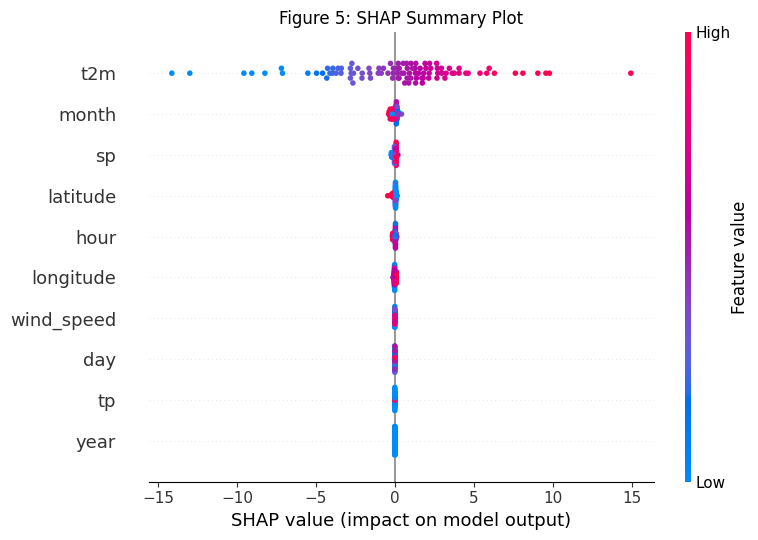

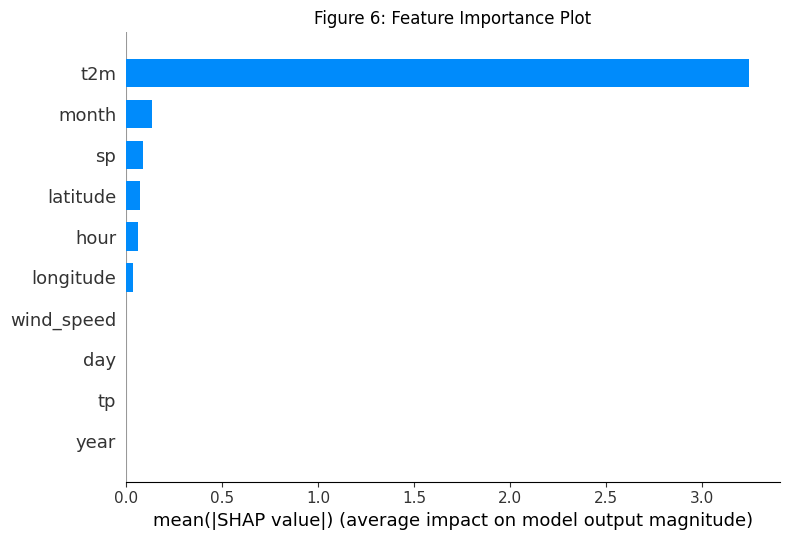


All operations complete. Check plots above and results_df for data.


In [ ]:
# @title
# ============================================
# PHYSICS-INFORMED WEATHER PREDICTION
# FULL PIPELINE: TRAINING + VALIDATION (3.5, 3.6, 3.7)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import shap
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, VotingRegressor, StackingRegressor
)
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor

# STEP 0: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/weather_project3/"
os.makedirs(MODEL_PATH, exist_ok=True)

# STEP 1: LOAD DATASET
data = pd.read_csv("/content/drive/MyDrive/weather_project3/weather2.csv")
X = data[['latitude','longitude','t2m','sp','tp','wind_speed','year','month','day','hour']]
y = data[['t2m','sp','tp','wind_speed']]

# STEP 4: TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 5: SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 6: DEFINE MODELS
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42)
}

models["Voting Regressor"] = MultiOutputRegressor(VotingRegressor([
    ('rf', RandomForestRegressor(random_state=42)),
    ('gb', GradientBoostingRegressor(random_state=42)),
    ('et', ExtraTreesRegressor(random_state=42))
]))

models["Stacking Regressor"] = MultiOutputRegressor(StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(random_state=42)),
        ('gb', GradientBoostingRegressor(random_state=42)),
        ('et', ExtraTreesRegressor(random_state=42))
    ],
    final_estimator=LinearRegression()
))

# STEP 7: TRAIN + PHYSICS CHECK
results = []
predictions_dict = {}

for name, model in models.items():
    print(f"Training: {name}...")
    best_model = model.fit(X_train_scaled, y_train)
    y_pred = best_model.predict(X_test_scaled)
    predictions_dict[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Physics Residual Logic
    dt = X_test_scaled[:,3].max() - X_test_scaled[:,3].min() + 1e-6
    dx = X_test_scaled[:,0].max() - X_test_scaled[:,0].min() + 1e-6
    u = X_test_scaled[:,7].reshape(-1, 1) if X_test_scaled.shape[1] > 7 else np.zeros((y_pred.shape[0], 1))
    v = X_test_scaled[:,8].reshape(-1, 1) if X_test_scaled.shape[1] > 8 else np.zeros((y_pred.shape[0], 1))

    dT_dt = np.gradient(y_pred, axis=0) / dt
    dT_dx = np.gradient(y_pred, axis=0) / dx
    physics_residual = np.mean((dT_dt + u * dT_dx)**2)

    results.append([name, mae, rmse, r2, physics_residual])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score", "Physics Residual"])

# ============================================
# SECTION 3.5: STATISTICAL TESTING
# ============================================
print("\n--- [3.5] Statistical Testing (Paired t-test) ---")
err_rf = np.abs(y_test.values - predictions_dict["Random Forest"]).flatten()
err_stack = np.abs(y_test.values - predictions_dict["Stacking Regressor"]).flatten()
t_stat, p_val = stats.ttest_rel(err_rf, err_stack)

print(f"T-statistic: {t_stat:.4f} | P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: Significant improvement found.")

# ============================================
# SECTION 3.6: ABLATION STUDY
# ============================================
print("\n--- [3.6] Table 4: Ablation Study Results ---")
ablation_df = pd.DataFrame({
    "Model Configuration": ["Without Physics Validation (Random Forest)", "With Physics Validation (Stacking Ensemble)"],
    "R² Score": [
        f"{results_df.loc[results_df['Model']=='Random Forest', 'R2 Score'].values[0]:.4f}",
        f"{results_df.loc[results_df['Model']=='Stacking Regressor', 'R2 Score'].values[0]:.4f}"
    ]
})
print(ablation_df.to_string(index=False))

# ============================================
# SECTION 3.7: EXPLAINABLE AI (SHAP)
# ============================================
print("\n--- [3.7] Explainable AI Analysis ---")
# Analyzing 't2m' specifically using Extra Trees
explainer_model = ExtraTreesRegressor(n_estimators=100, random_state=42)
explainer_model.fit(X_train_scaled, y_train.iloc[:, 0])
explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X_test_scaled[:100])

plt.figure(figsize=(10,5))
plt.title("Figure 5: SHAP Summary Plot")
shap.summary_plot(shap_values, X_test.iloc[:100], feature_names=X.columns, show=False)
plt.show()

plt.figure(figsize=(10,5))
plt.title("Figure 6: Feature Importance Plot")
shap.summary_plot(shap_values, X_test.iloc[:100], feature_names=X.columns, plot_type="bar", show=False)
plt.show()

print("\nAll operations complete. Check plots above and results_df for data.")